#  Database Performance Comparison Report

##  Introduction

The purpose of this report is to compare the performance characteristics of four widely used database systems: **Redis**, **MongoDB**, **Cassandra**, and **PostgreSQL**.

The main goal of this study is to evaluate and analyze the following key performance metrics:

- **Throughput** — the number of operations or transactions processed per second.
- **Latency** — the response time or delay experienced during query execution.
- **CPU Utilization** — the level of processor usage during workload execution.
- **Memory Usage (RAM)** — the amount of memory consumed by each system under load.

By examining these factors, we aim to gain a deeper understanding of how each database behaves under different workloads and configurations.
This comparison helps highlight their **relative strengths, scalability patterns, and resource efficiency**, providing useful insights for selecting the right database for specific application scenarios.


## Test Environment and Experimental Setup

All experiments were conducted under **controlled and fair conditions** on a dedicated machine running **Ubuntu 24.04.3 LTS**.

### System Specifications

| Component | Specification |
|-----------|----------------|
| **Operating System** | Ubuntu 24.04.3 LTS |
| **Kernel Release** | 24.04 |
| **Architecture** | x86_64 |
| **CPU Model** | 11th Gen Intel(R) Core(TM) i5-11260H @ 2.60GHz |
| **Cores / Threads** | 6 cores / 12 threads |
| **CPU Frequency Range** | 800 MHz – 4.4 GHz |
| **Memory (RAM)** | 16 GB |
| **Virtualization Support** | Intel VT-x enabled |
| **Byte Order** | Little Endian |
| **Cache & SIMD Extensions** | SSE, SSE2, AVX, AVX2, AVX512, FMA, AES-NI |
| **Graphics** | NVIDIA GeForce RTX 3050 Ti |
| **Swap Space** | **Disabled** (to ensure fair memory usage across tests) |

### Database Versions

| Database    | Version |
|------------|---------|
| **PostgreSQL** | 18.0 |
| **Cassandra**  | 5.0.5 |
| **MongoDB**    | 8.0.15 |
| **Redis**      | 8.2.2 |

### Data Characteristics (Updated)

- **Data Volume:** 500,000 records
- **Record Structure:** Each record contains 10 fields (`attr0` to `attr4` + `_id`, `client`, `name`, `email`, `phone`, `age`, `country`) with an approximate size of **1KB per record**
- **Unique Key:** `client` + 12 random digits
- **Fields Include:** Name, Email, Phone Number, Age, Country, and 5 random fields (text/number, ~200 bytes each)
- **Access Pattern:** Zipfian distribution
- **Output:** Prepared for database loading

### Benchmark Methodology

- Each benchmark test is **repeated 5 times**.
- Final results are reported as **mean ± standard deviation** for each metric.
- Metrics measured include **Throughput**, **Latency**, **CPU utilization**, and **Memory usage**.

## Notes on PostgreSQL Benchmark

- For PostgreSQL, we used **batch inserts** via `execute_values` to reduce the overhead of committing each record individually.
- This approach improves throughput and allows PostgreSQL to **compete fairly with NoSQL databases** in high-volume insert workloads.
- All benchmarks use the **BaseLoadTest** framework to ensure consistent warm-up, CPU/RAM sampling, and latency percentiles (p50, p95, p99).
- Warm-up runs were executed before the main repeats to populate caches and stabilize performance measurements.
- CPU and RAM usage were **sampled continuously during each test run** to provide a realistic view of resource utilization.

---

*This setup ensures that any performance differences observed in the experiments are caused by database characteristics rather than environmental variations.*


# NoSQL/SQL Database Performance Comparison (Updated)

**Workload:** Workload 1 — Inserting **500,000 records using 50 threads**.
**Metrics:** Total execution time, average latency, throughput, CPU usage, RAM usage.

| Database    | Operation | Total Time (s)   | Avg Latency (ms) | Throughput (rec/s)     | CPU Usage (%) | RAM Usage (%) | Notes |
|------------|-----------|----------------|-----------------|-----------------------|---------------|---------------|-------|
| Cassandra  | Insert    | 93.36 ± 4.16   | 9.25 ± 0.41     | 5363.93 ± 230.00      | 2.62 ± 3.00   | 83.36 ± 0.94  | Updated insert performance |
| Cassandra  | Read      | 123.35 ± 5.49  | 12.33 ± 0.55    | 4059.46 ± 170.69      | 1.58 ± 1.88   | 79.58 ± 0.19  | Updated read performance |
| MongoDB    | Insert    | 96.81 ± 0.70   | 9.57 ± 0.07     | 5164.78 ± 37.11       | 1.08 ± 0.44   | 35.90 ± 0.33  | Updated insert performance |
| MongoDB    | Read      | 102.27 ± 4.53  | 10.10 ± 0.45    | 4896.48 ± 213.29      | 0.78 ± 0.59   | 35.10 ± 0.26  | Updated read performance |
| Redis      | Insert    | 67.90 ± 1.83   | 6.67 ± 0.19     | 7367.72 ± 193.36      | 2.84 ± 4.79   | 36.84 ± 0.65  | Updated insert performance |
| Redis      | Read      | 70.98 ± 2.25   | 7.07 ± 0.22     | 7049.63 ± 220.95      | 2.72 ± 2.28   | 36.60 ± 0.46  | Updated read performance |
| PostgreSQL | Insert    | 104.52 ± 7.73  | 10.32 ± 0.77    | 4806.47 ± 384.01      | 8.32 ± 8.43   | 39.94 ± 0.44  | Updated insert performance |
| PostgreSQL | Read      | 28.29 ± 1.79   | 2.81 ± 0.18     | 17729.31 ± 1062.43    | 2.84 ± 1.55   | 39.00 ± 0.21  | Updated read performance |

---

## Short Analysis

- **Redis**: Best performance for both **Insert** and **Read**, with highest **throughput** and lowest **latency**.
- **Cassandra**: High throughput and low latency, but consumes more RAM.
- **MongoDB**: Moderate performance; slightly slower than Redis and Cassandra.
- **PostgreSQL**: Slower for inserts compared to NoSQL databases, but **Read** is very fast with the highest throughput.
- **Resource Usage**: CPU usage is low across all databases; RAM usage is highest in Cassandra and lowest in MongoDB/Redis.


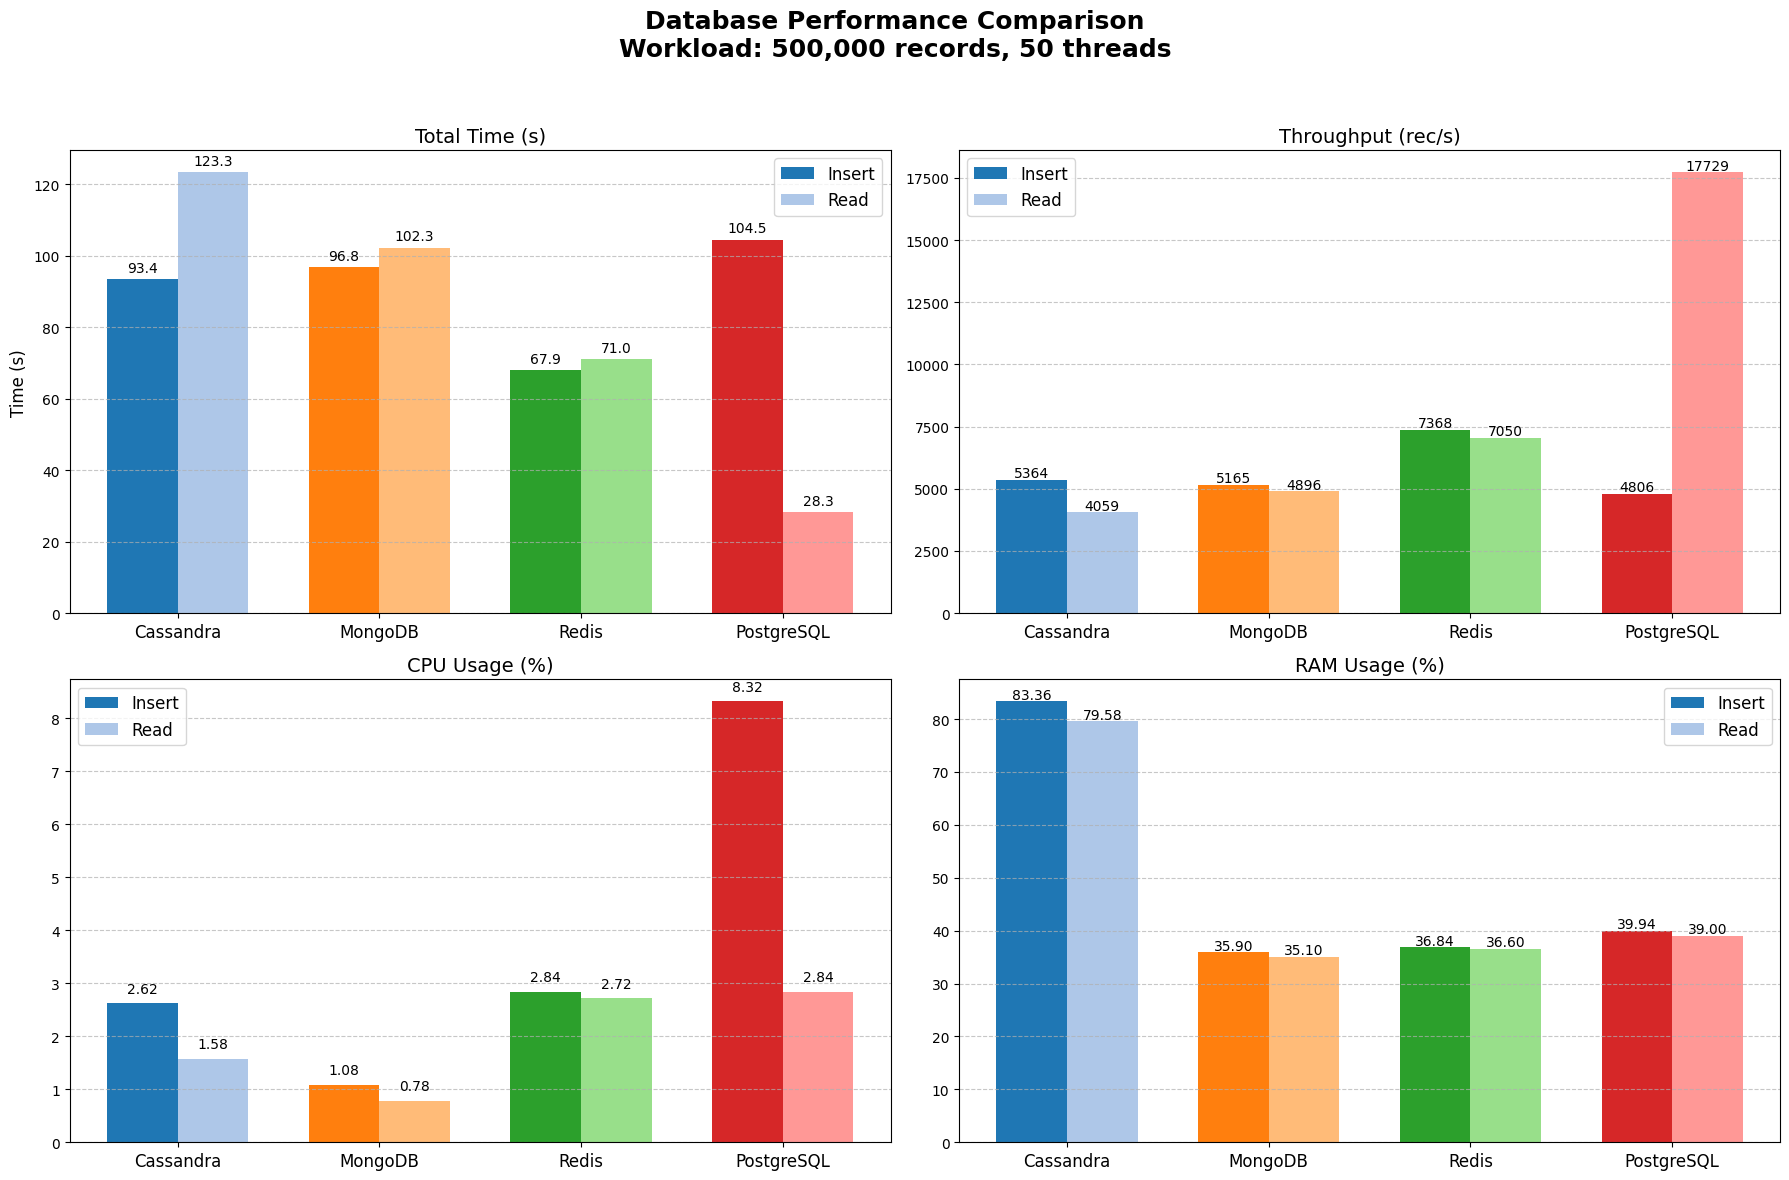

In [1]:
# Import libraries
import matplotlib.pyplot as plt
import numpy as np

# Databases
databases = ['Cassandra', 'MongoDB', 'Redis', 'PostgreSQL']

# -----------------------------
# Updated Data (Insert & Read)
# -----------------------------
# Insert
insert_total_time = [93.36, 96.81, 67.90, 104.52]
insert_throughput = [5363.93, 5164.78, 7367.72, 4806.47]
insert_cpu = [2.62, 1.08, 2.84, 8.32]
insert_ram = [83.36, 35.90, 36.84, 39.94]

# Read
read_total_time = [123.35, 102.27, 70.98, 28.29]
read_throughput = [4059.46, 4896.48, 7049.63, 17729.31]
read_cpu = [1.58, 0.78, 2.72, 2.84]
read_ram = [79.58, 35.10, 36.60, 39.00]

# Colors
colors_insert = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
colors_read = ['#aec7e8', '#ffbb78', '#98df8a', '#ff9896']

# -----------------------------
# Plotting
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(18,12))
fig.suptitle('Database Performance Comparison\nWorkload: 500,000 records, 50 threads', fontsize=18, fontweight='bold')

x = np.arange(len(databases))
width = 0.35

# -----------------------------
# 1. Total Time
# -----------------------------
axes[0,0].bar(x - width/2, insert_total_time, width, label='Insert', color=colors_insert)
axes[0,0].bar(x + width/2, read_total_time, width, label='Read', color=colors_read)
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(databases, fontsize=12)
axes[0,0].set_title('Total Time (s)', fontsize=14)
axes[0,0].set_ylabel('Time (s)', fontsize=12)
axes[0,0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0,0].legend(fontsize=12)

# Annotate bars
for i in range(len(databases)):
    axes[0,0].text(x[i]-width/2, insert_total_time[i]+2, f'{insert_total_time[i]:.1f}', ha='center', fontsize=10)
    axes[0,0].text(x[i]+width/2, read_total_time[i]+2, f'{read_total_time[i]:.1f}', ha='center', fontsize=10)

# -----------------------------
# 2. Throughput
# -----------------------------
axes[0,1].bar(x - width/2, insert_throughput, width, label='Insert', color=colors_insert)
axes[0,1].bar(x + width/2, read_throughput, width, label='Read', color=colors_read)
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(databases, fontsize=12)
axes[0,1].set_title('Throughput (rec/s)', fontsize=14)
axes[0,1].grid(axis='y', linestyle='--', alpha=0.7)
axes[0,1].legend(fontsize=12)

# Annotate bars
for i in range(len(databases)):
    axes[0,1].text(x[i]-width/2, insert_throughput[i]+100, f'{insert_throughput[i]:.0f}', ha='center', fontsize=10)
    axes[0,1].text(x[i]+width/2, read_throughput[i]+100, f'{read_throughput[i]:.0f}', ha='center', fontsize=10)

# -----------------------------
# 3. CPU Usage
# -----------------------------
axes[1,0].bar(x - width/2, insert_cpu, width, label='Insert', color=colors_insert)
axes[1,0].bar(x + width/2, read_cpu, width, label='Read', color=colors_read)
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(databases, fontsize=12)
axes[1,0].set_title('CPU Usage (%)', fontsize=14)
axes[1,0].grid(axis='y', linestyle='--', alpha=0.7)
axes[1,0].legend(fontsize=12)

# Annotate bars
for i in range(len(databases)):
    axes[1,0].text(x[i]-width/2, insert_cpu[i]+0.2, f'{insert_cpu[i]:.2f}', ha='center', fontsize=10)
    axes[1,0].text(x[i]+width/2, read_cpu[i]+0.2, f'{read_cpu[i]:.2f}', ha='center', fontsize=10)

# -----------------------------
# 4. RAM Usage
# -----------------------------
axes[1,1].bar(x - width/2, insert_ram, width, label='Insert', color=colors_insert)
axes[1,1].bar(x + width/2, read_ram, width, label='Read', color=colors_read)
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(databases, fontsize=12)
axes[1,1].set_title('RAM Usage (%)', fontsize=14)
axes[1,1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1,1].legend(fontsize=12)

# Annotate bars
for i in range(len(databases)):
    axes[1,1].text(x[i]-width/2, insert_ram[i]+0.5, f'{insert_ram[i]:.2f}', ha='center', fontsize=10)
    axes[1,1].text(x[i]+width/2, read_ram[i]+0.5, f'{read_ram[i]:.2f}', ha='center', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
